In [4]:
# Листинг 2 – Предобработка данных в R
library(caret)
library(nnet)

# Чтение данных
df <- read.csv("mxmh_survey_results.csv")

# Удаление столбца Timestamp
if ("Timestamp" %in% colnames(df)) {
  df$Timestamp <- NULL
}

# Кодирование категориальных признаков
cat_columns <- names(df)[sapply(df, is.character)]
for (col in cat_columns) {
  # Преобразуем в фактор с сохранением порядка уровней
  df[[col]] <- factor(df[[col]])
  # Кодируем в числовой формат
  df[[col]] <- as.numeric(df[[col]])
}

# Заполнение пропусков в числовых столбцах
numeric_columns <- names(df)[sapply(df, is.numeric)]
for (col in numeric_columns) {
  df[[col]][is.na(df[[col]])] <- mean(df[[col]], na.rm = TRUE)
}

# Преобразуем целевую переменную в фактор
df$Music.effects <- as.factor(df$Music.effects)

# Подготовка данных для классификации
X_class <- df[, !names(df) %in% c("Music.effects", "Anxiety", "Depression")]
y_class <- df$Music.effects
temp_class <- cbind(X_class, Music.effects = y_class)

# Разделение на train/test для классификации
set.seed(42)
trainIndex_class <- createDataPartition(temp_class$Music.effects, p = 0.7, list = FALSE)
train_class <- temp_class[trainIndex_class, ]
test_class <- temp_class[-trainIndex_class, ]
# Разделение на train/test для регрессии
trainIndex_reg <- createDataPartition(df$Anxiety, p=0.7, list=FALSE)
train_reg <- df[trainIndex_reg, ]
test_reg <- df[-trainIndex_reg, ]


In [ ]:
# Листинг 4 – Логистическая регрессия в R (исправленный)
# Обучение модели
model_log <- multinom(Music.effects ~ ., data = train_class)

# Прогнозирование на тестовых данных
pred_class <- predict(model_log, newdata = test_class)

# Преобразуем предсказания и тестовые данные в факторы с одинаковыми уровнями
levels_test <- levels(test_class$Music.effects)
pred_class <- factor(pred_class, levels = levels_test)
actual_class <- factor(test_class$Music.effects, levels = levels_test)

# Оценка точности модели
conf_matrix <- confusionMatrix(pred_class, actual_class)
accuracy <- conf_matrix$overall["Accuracy"]
print("Метрики классификации: ")
print(paste("Accuracy:", round(accuracy, 2)))
print(conf_matrix)
# Листинг 6 
model_lin <- lm(Anxiety ~ ., data = train_reg)
pred_reg <- predict(model_lin, newdata = test_reg)

# Метрики
mse <- mean((test_reg$Anxiety - pred_reg)^2)
mae <- mean(abs(test_reg$Anxiety - pred_reg)) # MAE
r2 <- 1 - sum((test_reg$Anxiety - pred_reg)^2) / sum((test_reg$Anxiety - mean(test_reg$Anxiety))^2) # R^2
print("Метрики регрессии: ")
# Вывод метрик
print(paste("MSE:", round(mse, 2)))
print(paste("MAE:", round(mae, 2)))
print(paste("R-squared (R2):", round(r2, 2)))

# weights:  124 (90 variable)
initial  value 716.714185 
iter  10 value 385.203863
iter  20 value 349.426677
iter  30 value 324.087913
iter  40 value 314.270509
iter  50 value 309.649226
iter  60 value 307.083090
iter  70 value 304.983572
iter  80 value 304.178135
iter  90 value 304.133313
iter 100 value 304.121067
final  value 304.121067 
stopped after 100 iterations
[1] "Метрики классификации: "
[1] "Accuracy: 0.73"
Confusion Matrix and Statistics

          Reference
Prediction   1   2   3   4
         1   0   1   7   0
         2   2 155  39   4
         3   0   5   4   1
         4   0   1   0   0

Overall Statistics
                                         
               Accuracy : 0.726          
                 95% CI : (0.6619, 0.784)
    No Information Rate : 0.7397         
    P-Value [Acc > NIR] : 0.708          
                                         
                  Kappa : 0.1263         
                                         
 Mcnemar's Test P-Value : NA      

[1] "MSE: 5.14"


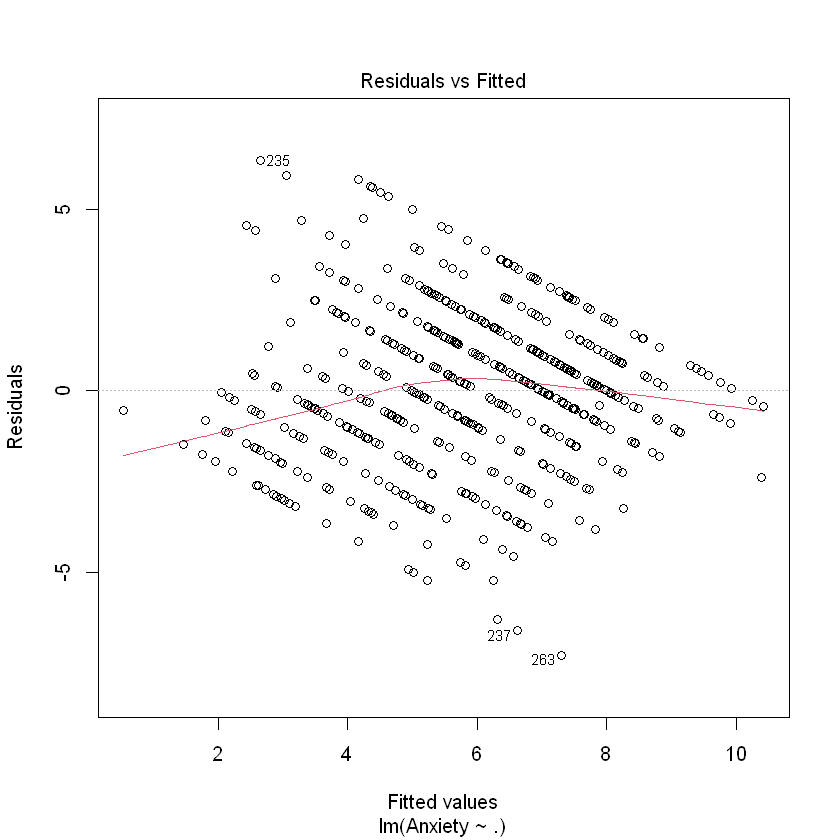

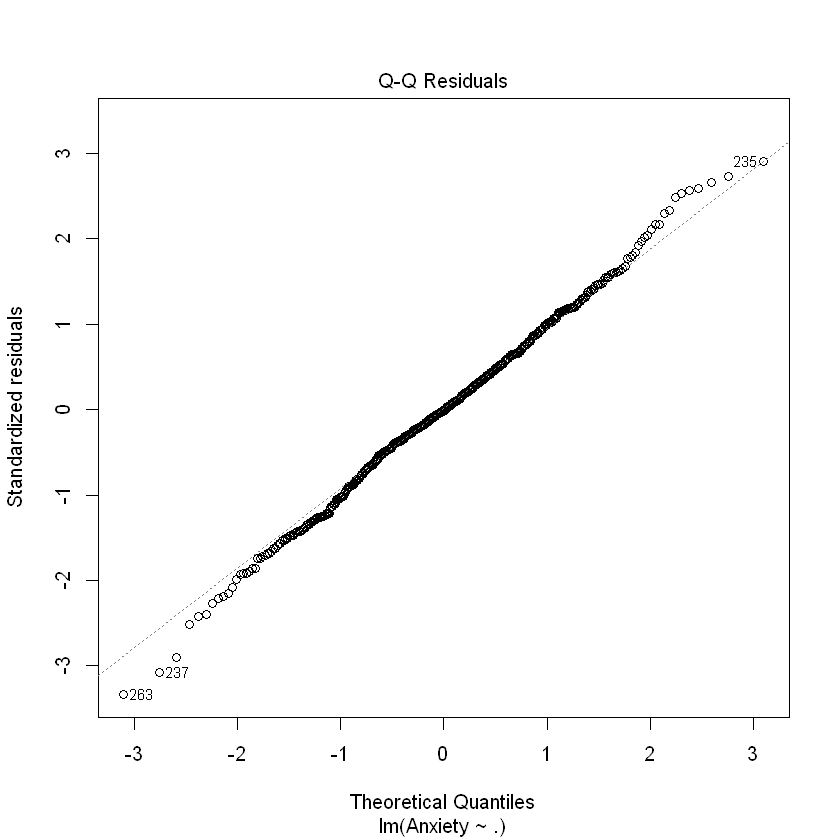

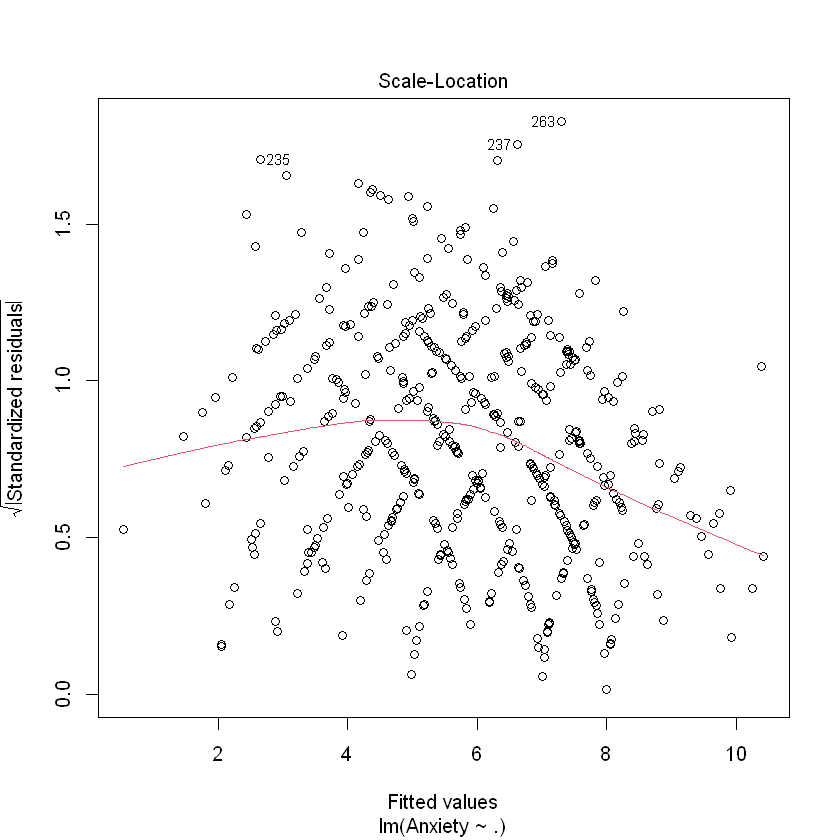

Warning message in sqrt(crit * p * (1 - hh)/hh):
"созданы NaN"
Warning message in sqrt(crit * p * (1 - hh)/hh):
"созданы NaN"


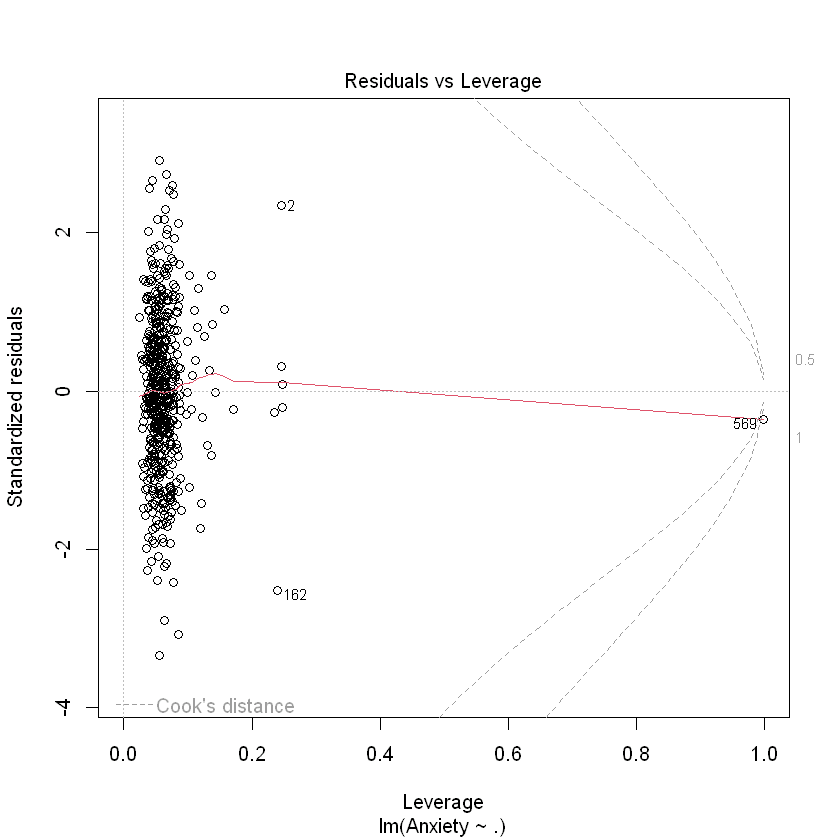

In [8]:
plot(model_lin)